# Introduction

This project looks to investigate the relationship between weather conditions and national electricity demand in Frnace. 
Specifically, the research question is: **How does the daily temperature impact the electricity consumption of French households?**

This is a highly relevant topic because heating in residential buildings in France relies heavily on electricity and is therefore very sensitive to temperature changes. Understanding this link is very important for the grid management of electricity during the winter time. Namely, the distribution of electricity increasingly takes weather forecasts as a predictor for electricity demand levels. 

In order to do this, I am sourcing my data from an open API: the **Enedis Open Data** portal. Enedis is the French monopoly for distribution of electricity, the last step of the electricity supply chain that connecs low voltage electricity directly to the consumer.  Their daily electricity balance dataset aligns well with the research question as it provides both the daily residential consumption and the temperature, all in one place. We will look at data from the past 5 years (2021-2026).

# Imports and parameters

These are the imports & parameters for this notebook

In [34]:
import requests
import io
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
START_DATE = "2021-03-28"
END_DATE = "2026-03-27"

# Data acquisition and processing

To build my dataset, I fetch it directly from the *Puissances Électriques au pas journalier* (`bilan-electrique-jour`) API. Enedis allows a direct CSV export, which I read using Pandas, isolating just the date, the residential consumption (`consommation_profilee_res`), and the actual temperature (`temperature_reelle_lissee`).

Because this is a small-scale project, I wanted to focus only on residential demand and the distribution data using the Enedis portal. A larger project could have looked at the total RTE grid data and included additional factors which drive consumption across the year. However, this could potentially be more risky in terms of association of cause and effect given that nationally there are many more additional variables that drive electricity consumption to take in consideration. By isolating only the residential sector we have a shorter task at hand but also potentially a more accurate one. Moreover, another limitation of the following project is that the consumption is aggregated across France and the temperature is an average of the degrees registred. However, there can be some within-country variation in terms of size of households (impacting base load energy consumption) as well as heating technologies (more efficent heaters will consume less electricity) and finally also in terms of temperatures (France has three distinct climate zones). Enedis seems to not provide such granular data. 

In [12]:
def get_enedis_daily_data(start, end):
    url = 'https://opendata.enedis.fr/data-fair/api/v1/datasets/bilan-electrique-jour/lines'
    
    # size: 2000 ensures we get all 5 years worth of data in a single request and we get the columns we need.
    params = {
        'size': 2000, 
        'select': 'jour,consommation_profilee_res,temperature_reelle_lissee',
        'qs': f'jour:[{start} TO {end}]'
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status() 
    
    data = response.json()
    df = pd.DataFrame(data['results'])
    
    # Dates to be formatted
    df['jour'] = pd.to_datetime(df['jour'])
    df.set_index('jour', inplace=True)
    df.sort_index(inplace=True)
    
    cols_to_keep = ['consommation_profilee_res', 'temperature_reelle_lissee']
    df = df[cols_to_keep].copy()
    
    # Column renamed for clarity
    df.columns = ['residential_mw', 'actual_temp_celsius']
    
    # Convert Watts to Megawatts
    df['residential_mw'] = df['residential_mw'] / 1_000_000
    
    return df

try:
    df_final = get_enedis_daily_data(START_DATE, END_DATE).dropna()
    display(df_final.head())
    print(f"Total rows: {len(df_final)}")

except Exception as e:
    print(f"An error occurred: {e}")

,residential_mw,actual_temp_celsius
jour,,
2021-03-28,19435.572013,10.1
2021-03-29,16672.571351,11.7
2021-03-30,14512.390527,13.5
2021-03-31,13640.170781,14.7
2021-04-01,13313.950790,15.5


Total rows: 1826


# 1st visualization: seasonal trends

The first figure tries to displays the seasonality features of our data. Namely, the column chart represents the average weekly electricity demand, while the line curve on top tracks the average weekly temperature. This attempts to show the cyclical nature of French electricity consumption with winter months having drops in temperature and spikes in heating demand.

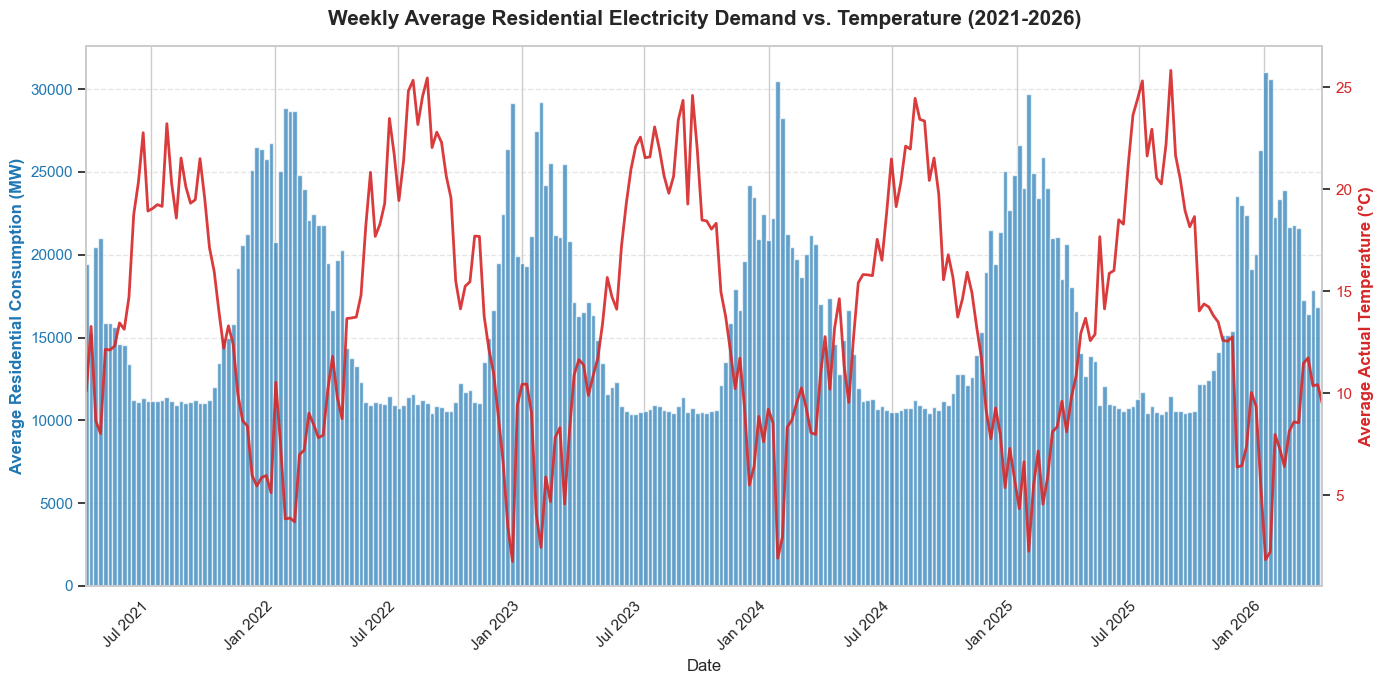

In [25]:
# Resample the daily data into weekly averages
df_weekly = df_final.resample('W').mean()

# Create the figure and the primary axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# We add electricity demand as the primary axis
ax1.bar(
    df_weekly.index, 
    df_weekly['residential_mw'], 
    color='#1f77b4', 
    alpha=0.7, 
    width=7, 
    label='Electricity Demand (MW)'
)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Average Residential Consumption (MW)', fontsize=12, color='#1f77b4', weight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# We format the x axis labels by having it start and end according to our database, place labels when it's january and july so we know when a year starts and is mid-way.
ax1.set_xlim(df_weekly.index.min(), df_weekly.index.max())
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

#We add temperature as the secondary axix
ax2 = ax1.twinx()  
ax2.plot(
    df_weekly.index, 
    df_weekly['actual_temp_celsius'], 
    color='#d62728', 
    linewidth=2, 
    alpha=0.9,
    label='Temperature (°C)'
)
ax2.set_ylabel('Average Actual Temperature (°C)', fontsize=12, color='#d62728', weight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.grid(False) 

#We add the title to the figure
plt.title('Weekly Average Residential Electricity Demand vs. Temperature (2021-2026)', fontsize=15, pad=15, weight='bold')

fig.tight_layout()
plt.show()

# 2nd Visualization: linear regression

Now we take all of the data points, disregarding the date, and simply plot temperature against residential electricity consumption, expecting to see a clear negative correlation.

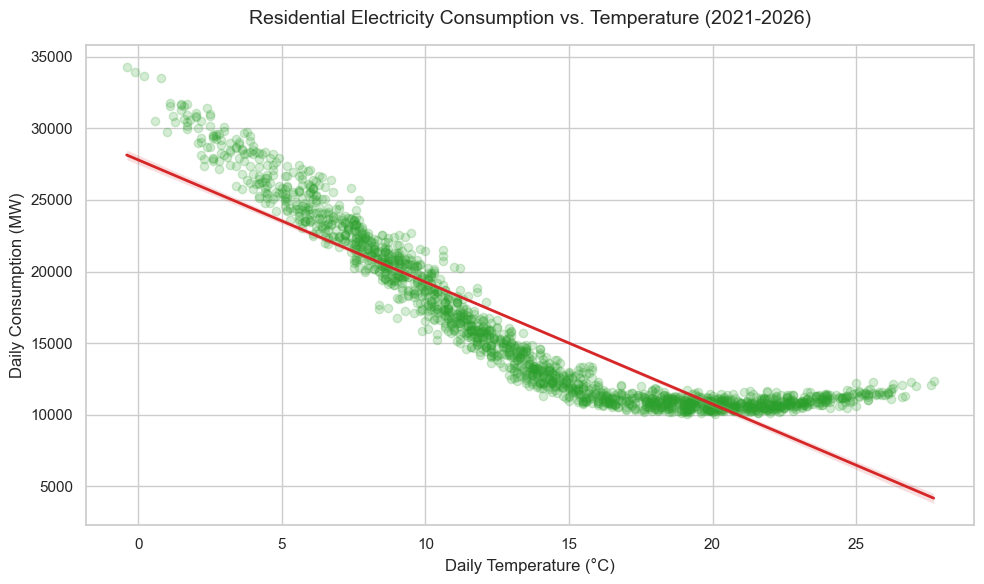

In [26]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Plot the scatter with a OLS regression line going through it.
plot = sns.regplot(
    data=df_final, 
    x="actual_temp_celsius", 
    y="residential_mw", 
    scatter_kws={'alpha': 0.2, 'color': '#2ca02c'}, 
    line_kws={'color': '#d62728', 'linewidth': 2}
)

plot.set_title('Residential Electricity Consumption vs. Temperature (2021-2026)', fontsize=14, pad=15)
plot.set_xlabel('Daily Temperature (°C)', fontsize=12)
plot.set_ylabel('Daily Consumption (MW)', fontsize=12)

plt.tight_layout()
plt.show()

# 1st Regression

To quantify the visual trend, I am running a simple OLS regression.

In [27]:
# We first define temperature as the independent variable and the consumption as the dependent
X = sm.add_constant(df_final['actual_temp_celsius'])
y = df_final['residential_mw']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         residential_mw   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     9119.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:53:31   Log-Likelihood:                -16771.
No. Observations:                1826   AIC:                         3.355e+04
Df Residuals:                    1824   BIC:                         3.356e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 2.78e+04    135.052    205.857      0.000    2.75e+04    2.81e+04
actual_temp_celsius  -853.0244      8.933    -95.495      0.000    -870.544    -835.505
==============================================================================
Omnibus:                       80.656   Durbin-Watson:                   0.093
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               84.636
Skew:                           0.500   Prob(JB):                     4.18e-19
Kurtosis:                       2.666   Cond. No.                         37.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 1st Regression: results
The temperature coefficient tell us exactly that French households need 853 MW of power less for every 1°C increase in temperature. However, are we sure that the linear regression fits the data correctly? 

# 2nd Regression: quadratic model

As seen in the initial scatter plot, a simple linear regression does not really fit the data. The relationship curves because electricity demand plateaus and hits the base load in the summer (the minimum a house needs to function such as lighting and appliances). However, one can see it rises exponentially when it's cold out. 

To better model this, I am adding a quadratic term (temperature squared) to my OLS regression. I have also updated the visualization to fit a polynomial curve (`order=2`).

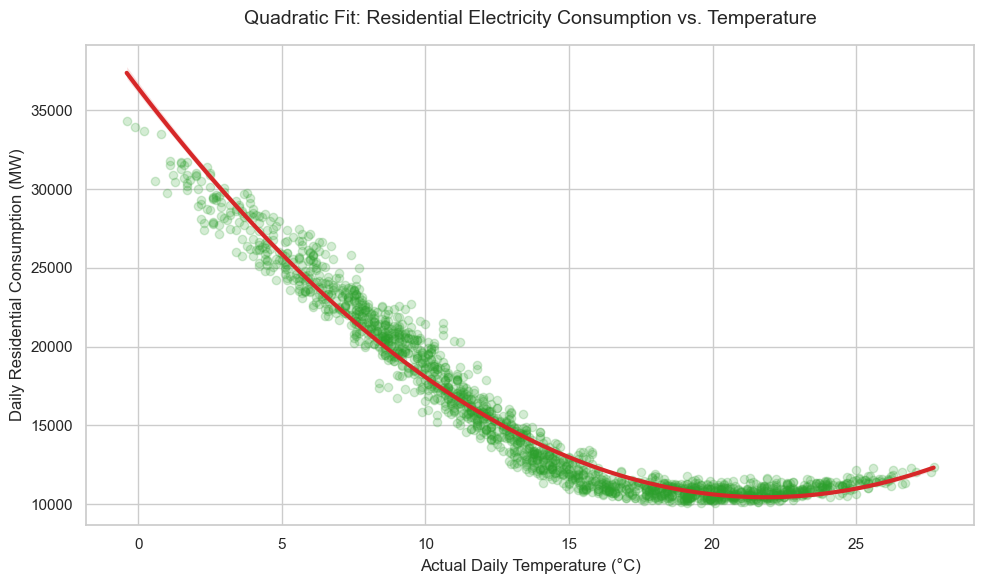

                            OLS Regression Results                            
Dep. Variable:         residential_mw   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                 2.746e+04
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:55:35   Log-Likelihood:                -15268.
No. Observations:                1826   AIC:                         3.054e+04
Df Residuals:                    1823   BIC:                         3.056e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3.641e+04    

In [28]:
plt.figure(figsize=(10, 6))

plot = sns.regplot(
    data=df_final, 
    x="actual_temp_celsius", 
    y="residential_mw", 
    order=2, 
    scatter_kws={'alpha': 0.2, 'color': '#2ca02c'}, 
    line_kws={'color': '#d62728', 'linewidth': 3}
)
plot.set_title('Quadratic Fit: Residential Electricity Consumption vs. Temperature', fontsize=14, pad=15)
plot.set_xlabel('Actual Daily Temperature (°C)', fontsize=12)
plot.set_ylabel('Daily Residential Consumption (MW)', fontsize=12)
plt.tight_layout()
plt.show()

df_final['temp_squared'] = df_final['actual_temp_celsius'] ** 2

X_quad = sm.add_constant(df_final[['actual_temp_celsius', 'temp_squared']])
y = df_final['residential_mw']

model_quad = sm.OLS(y, X_quad).fit()
print(model_quad.summary())

# 2nd Regression: results

Clearly, the non-linear relationship fits the data much better, with a R-squared that has significantly increased with respect to the previous regression. Moreover, the y-intercept, which would represent the power load needed when temperature hits freezing temperature is nearly 10,000 MW greater compared to the last regression. The inclusion of a positive quadratic term which is statistically significant proves a non-linear relationship between temperature and consumption as it forces the curve to flatten around 15°C to 20°C. However, given that the coefficients are potentially hard to interpret, we will provide an alternative iteration of representing this relationship.

# 3rd Regression: split into seasons as categorical explanatory variables

The non-linearity lies in the fact that a 1°C drop in summer time might provoke a different decision compared to a 1°C drop in winter time. 

Below, I place the data into the four seasons according to the date and visualize their individual regression lines. This single model calculates the temperature coefficient independently for Winter, Spring, Summer, and Autumn, allowing us to directly compare them in one table.

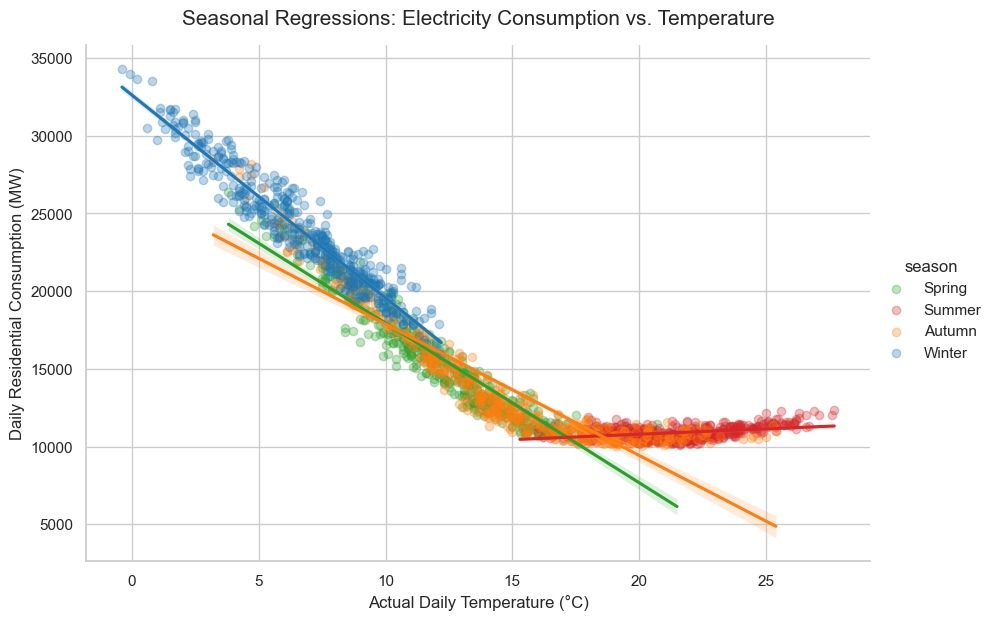

                            OLS Regression Results                            
Dep. Variable:         residential_mw   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     5837.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:38:50   Log-Likelihood:                -15525.
No. Observations:                1826   AIC:                         3.107e+04
Df Residuals:                    1818   BIC:                         3.111e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
seas

In [36]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_final['season'] = df_final.index.month.map(get_season)

sns.lmplot(
    data=df_final, 
    x="actual_temp_celsius", 
    y="residential_mw", 
    hue="season", 
    scatter_kws={'alpha': 0.3},
    height=6, 
    aspect=1.5,
    palette={'Winter': '#1f77b4', 'Spring': '#2ca02c', 'Summer': '#d62728', 'Autumn': '#ff7f0e'}
)
plt.title('Seasonal Regressions: Electricity Consumption vs. Temperature', fontsize=15, pad=15)
plt.xlabel('Actual Daily Temperature (°C)', fontsize=12)
plt.ylabel('Daily Residential Consumption (MW)', fontsize=12)
plt.show()

# Here we run the interaction OLS without needing the global intercept but rather just 4 different model coefficient results for each season
formula = 'residential_mw ~ season - 1 + actual_temp_celsius:season'
model_seasons = smf.ols(formula, data=df_final).fit()
print(model_seasons.summary())

# 3rd Regression: results

By looking at these new results we can see that the slope of the regressions are steeper in winter time and actually flips sign in summer. This probably suggests the limited but potentially growing use of air conditioning in summer when temperatures increase and residential consumptions increases as well, albeit at a lower magnitude with respect to the heating season. Another interesting insight is that households are less responsive to temperature changes in autumn compared to spring. This may be linked to calendar rules regarding when heating can start to be turned on. 

# 4th Regression: comparison across years

Similarly to the previous regression technique, I want to split the data in years and evaluate the differences across winters and analyse whether French households have become more or less thermosensitive over the last 5 years and which has been most difficult in terms of grid management. This can also be considered a proxy to evaluate whether energy efficiency policies and improvements in the residential sector have been working or not.

This exercise was also possible given that the dataset starts in march 2021 and ends in march 2026. Given a single winter spans two calendar years, I first map the data into discrete winter seasons (e.g., 2021-2022) and then visualize the regression for each specific winter and run an interaction OLS model to compare their unique temperature coefficients. Finally, it was interesting to have a final descriptive statistics summary table to show which winter had the coldest temperatures and the highest peak consumption.

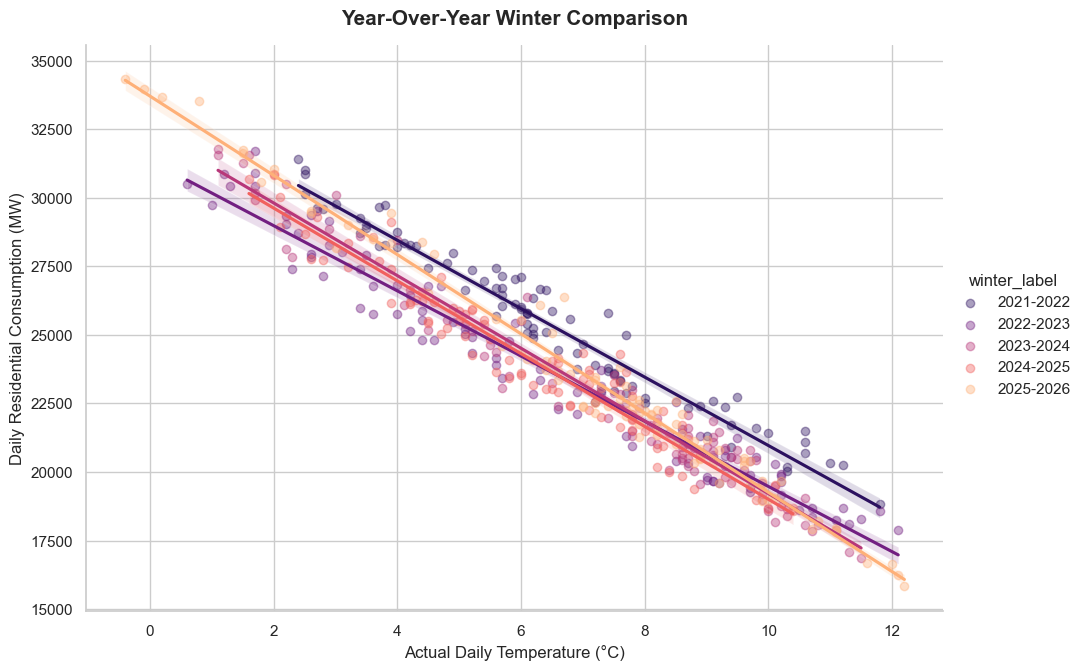

                            OLS Regression Results                            
Dep. Variable:         residential_mw   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     1195.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          2.37e-303
Time:                        19:15:24   Log-Likelihood:                -3615.2
No. Observations:                 451   AIC:                             7250.
Df Residuals:                     441   BIC:                             7292.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

,lowest_temp_celsius,average_temp_celsius,peak_consumption_mw,average_consumption_mw
winter_label,,,,
2021-2022,2.4,6.47,31402.94,25365.54
2022-2023,0.6,6.39,31711.44,23765.96
2023-2024,1.1,7.54,31759.80,22471.58
2024-2025,1.6,6.09,30876.06,24195.47
2025-2026,-0.4,7.25,34310.87,23237.60


In [ ]:
# We need to isolate just the winter months from our dataset and then create a label that groups Dec 2021 with Jan and Feb 2022, and so on for each winter season.
df_winters = df_final[df_final['season'] == 'Winter'].copy()
def assign_winter_year(date):
    if date.month == 12:
        return f"{date.year}-{date.year + 1}"
    else: # Jan or Feb
        return f"{date.year - 1}-{date.year}"

df_winters['winter_label'] = df_winters.index.map(assign_winter_year)

valid_winters = ['2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']
df_winters = df_winters[df_winters['winter_label'].isin(valid_winters)]

sns.lmplot(
    data=df_winters, 
    x="actual_temp_celsius", 
    y="residential_mw", 
    hue="winter_label", 
    scatter_kws={'alpha': 0.4},
    height=6.5, 
    aspect=1.5,
    palette="magma"
)

plt.title('Year-Over-Year Winter Comparison', fontsize=15, pad=15, weight='bold')
plt.xlabel('Actual Daily Temperature (°C)', fontsize=12)
plt.ylabel('Daily Residential Consumption (MW)', fontsize=12)
plt.show()

formula = 'residential_mw ~ winter_label - 1 + actual_temp_celsius:winter_label'
model_yoy = smf.ols(formula, data=df_winters).fit()
print(model_yoy.summary())

In [ ]:
# Finally, we create a summary table just to show how each year ranked in terms of peak energy demand and weather conditions.
winter_stats = df_winters.groupby('winter_label').agg(
    lowest_temp_celsius=('actual_temp_celsius', 'min'),
    average_temp_celsius=('actual_temp_celsius', 'mean'),
    peak_consumption_mw=('residential_mw', 'max'),
    average_consumption_mw=('residential_mw', 'mean')
).round(2)

display(winter_stats)

# 4th Regression: results

By looking at these new results we isolate how household's response to temperature changes has shifted over time. Firstly, given that we are keeping our regression to consider only winter seasons, the model strongly explains the variance in consumption purely on temperaturem as shown by the elevated R-squared. Secondly, we notice that 2022-2023 had the lowest intercept point as well as the flattest slope. Thirdly, the 25-26 winter was the most stressful for Enedis given that it experienced the absolute lowest daily temperature and, combined with its high thermosensitivity, triggered the highest peak consumption of the dataset.

We conclude the analysis by briefly taking a deep-dive into the atypical year of 2022-2023, a winter that was plagued by the international energy crisis as well as domestic problems with France's nuclear power plants. 

# Case Study: the 2022-2023 winter season

In late 2022, France faced historic unavailability of its nuclear reactor fleet due to stress corrosion. Facing the threat of winter blackouts, the government launched the "Plan de Sobriété Énergétique," urging households to lower their thermostats to 19°C. To evaluate whether households actually listened to the government, we isolate the baseline pre-Crisis winter (2021-2022) and compare it directly against the 2022-2023 season. By running a regression on just these two seasons, we can visually and mathematically measure the drop in structural electricity demand. We will want to test whether the difference between these two regression lines is statistically significant by running an interaction model with a dummy on whether the data point was in the crisis year or not. 


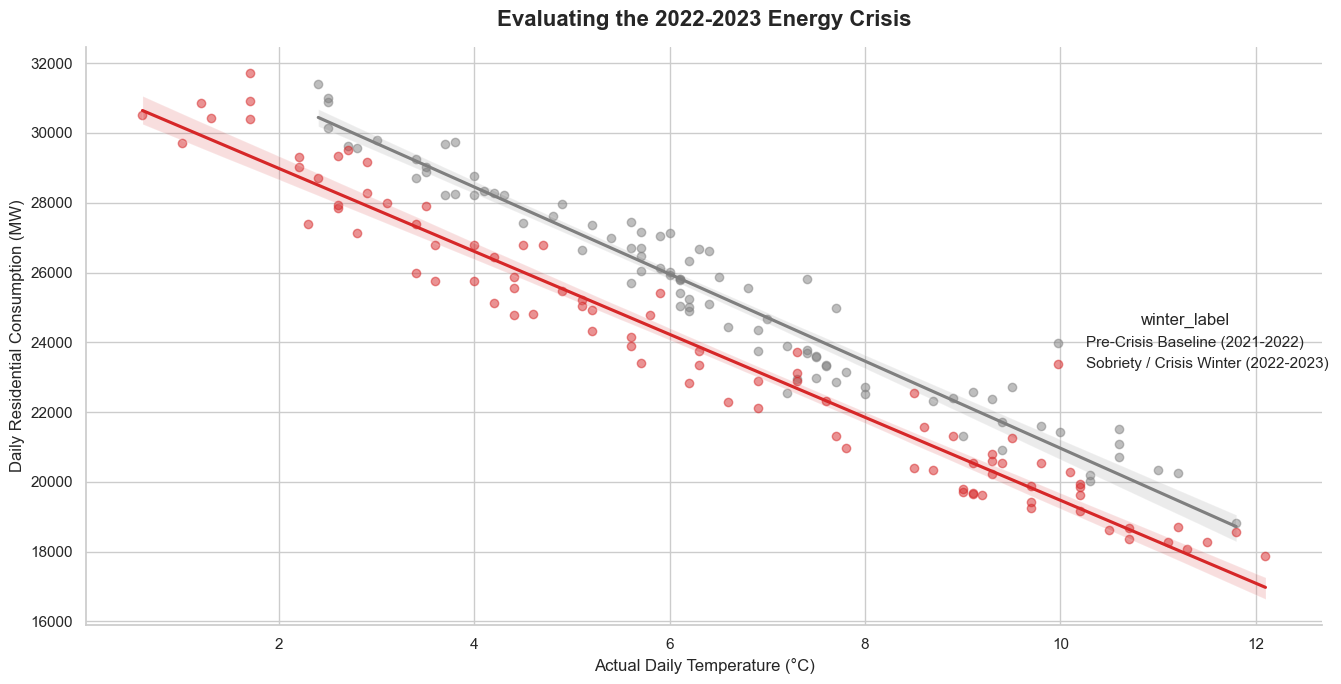

                            OLS Regression Results                            
Dep. Variable:         residential_mw   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     1250.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          2.20e-118
Time:                        19:38:23   Log-Likelihood:                -1445.4
No. Observations:                 180   AIC:                             2899.
Df Residuals:                     176   BIC:                             2911.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
# We filter the original winter dataset for just the two years we are comparing and rename the labels according to whether it was the crisis year or the baseline year. This will be needed to create the binary dummy variable.
df_sobriety = df_winters[df_winters['winter_label'].isin(['2021-2022', '2022-2023'])].copy()
df_sobriety['winter_label'] = df_sobriety['winter_label'].replace({
    '2021-2022': 'Pre-Crisis Baseline (2021-2022)',
    '2022-2023': 'Crisis Winter (2022-2023)'
})
df_sobriety['is_crisis'] = (df_sobriety['winter_label'] == 'Sobriety / Crisis Winter (2022-2023)').astype(int)

sns.set_theme(style="whitegrid")

plot = sns.lmplot(
    data=df_sobriety, 
    x="actual_temp_celsius", 
    y="residential_mw", 
    hue="winter_label", 
    palette={'Pre-Crisis Baseline (2021-2022)': '#7f7f7f', 'Crisis Winter (2022-2023)': '#d62728'},
    scatter_kws={'alpha': 0.5},
    height=7, 
    aspect=1.5
)

plt.title('Evaluating the 2022-2023 Energy Crisis', fontsize=16, pad=15, weight='bold')
plt.xlabel('Actual Daily Temperature (°C)', fontsize=12)
plt.ylabel('Daily Residential Consumption (MW)', fontsize=12)
plt.tight_layout()
plt.show()

formula = 'residential_mw ~ actual_temp_celsius * is_crisis'
model_interaction = smf.ols(formula, data=df_sobriety).fit()
print(model_interaction.summary())

# Case Study: results

The interaction model gives an insight into how the 2022-2023 energy crisis impacted French households. By examining the p-values and coefficients, we can see that the crisis year saw a statistically significant downward shift in the regression line. The key finding lies in the interaction terms which represents the difference in the slope between the two winters and can be considered as the behavioural response. Given that the p-value is not low enough, we can consider this difference not statistically significant. Given that the two lines are parallel we can suggest that while the French household structurally lowered their thermostats to 19°C (shifting the entire line down), their physical reaction to the temperature changes did not change and when it was colder out citizens turned their heating up at the exact same rate as they did the year before.

# Conclusion

In conclusion, the project set out to examine and quantify the link between temperature and electricity demand in France. The analysis proved that this relationship is deeply non-linear and highly seasonal. Below the 15°C threshold, residential demand spikes quadratically, revealing a steep sensitivity to temperature changes that leads to stress on the local distribution grid. The 2022-2023 energy crisis served as a practical application of this model. By utilizing a categorical interaction regression, the analysis attempted to isolate human behavior from weather patterns, proving that government warnings of outages and its enacted policies caused a statistically significant downward shift in baseline consumption, saving energy without fundamentally altering how people react to sudden cold snaps.

By focusing strictly on the residential sector we could exclude the industrial and commercial sectors. In this way the model inherently limited external macroeconomic noise (such as factory shutdowns or new technology adoption), creating a much purer proxy for daily human behavior and heating needs. However, the model contains various weaknesses, most notably a high risk of omitted variable bias. By relying exclusively on temperature and time, the analysis ignores other factors and fixed effects. This is quite clear when evaluating the 2022-2023 crisis. The observed drop in consumption is attributed solely to behavioural changes, but it is impossible to separate it from economic necessity without incorporating European electricity prices or inflation rates as control variables. Furthermore, the model treats France as one single block and does not consider within-country variances which could more accurately measure theromsensitivity. Moreover, it does not allow for additional socioeconomic and dwelling-level factors that may vary across the country. Despite these limitations, this project successfully demonstrates how temperature forecasting can provide strong predictions in terms of electricity consumption.